In [136]:
# Phase1_Optim.ipynb
# Author: Marianna Gabrielyan, 20260427
# Email: mgabr001@gmail.com

# 


In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')
import os

import random
from plotnine  import * 

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
import forestci as fci

import dice_ml
from quantile_forest import RandomForestQuantileRegressor
import shap



%matplotlib inline


In [138]:
# Read in input file

path = '/home/mgabr001/BrainGenix/BrainEmulationChallenge/src/models/autoassociative/NetmorphParOptim'
os.chdir(path)

df = pd.read_excel(open('ParameterSpace_700_samples-labeled.xlsx','rb'))    

print(df.shape)
print(df.columns)



(700, 9)
Index(['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight', 'usable_conns1',
       'usable_conns2'],
      dtype='str')


In [139]:
# Select Only Needed Columns

columnsA = ['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight', 'usable_conns1',
       'usable_conns2']


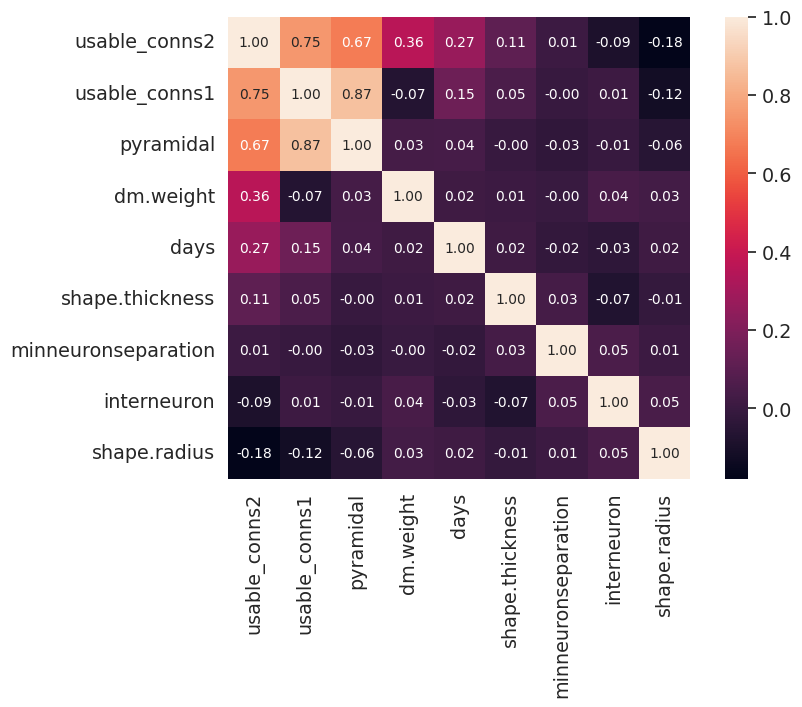

In [140]:

# correlation matrix
f, ax = plt.subplots(figsize=(9, 6))
k = 10 #number of variables for heatmap
corrmat = df[columnsA].corr()
cols = corrmat.nlargest(k, 'usable_conns2')['usable_conns2'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()
f.savefig('Correlation_Matrix.png')

## Create Training and Test datasets: split 80% and 20%

In [141]:
cols = ['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight']

In [142]:
X_train, X_test, y_train, y_test = train_test_split(df[cols],df['usable_conns2'], test_size=0.2, random_state=27)
X_train.shape

(560, 7)

In [143]:
print(X_train.head())
print(y_train.head()) 

     days  pyramidal  interneuron  minneuronseparation  shape.radius  \
623    22         48           72                   11           160   
372    20         48           40                   14           190   
246    22         64           16                   13           160   
38     21         88          128                   14           200   
562    24        104           32                   15           180   

     shape.thickness  dm.weight  
623               30        0.5  
372               20        0.9  
246               50        0.8  
38                40        0.6  
562               40        0.8  
623     193
372     208
246     521
38      311
562    1218
Name: usable_conns2, dtype: int64


In [144]:
clf = RandomForestRegressor(n_estimators=1000, bootstrap = True, oob_score = True, random_state = 27)
model = clf.fit(X_train, y_train)

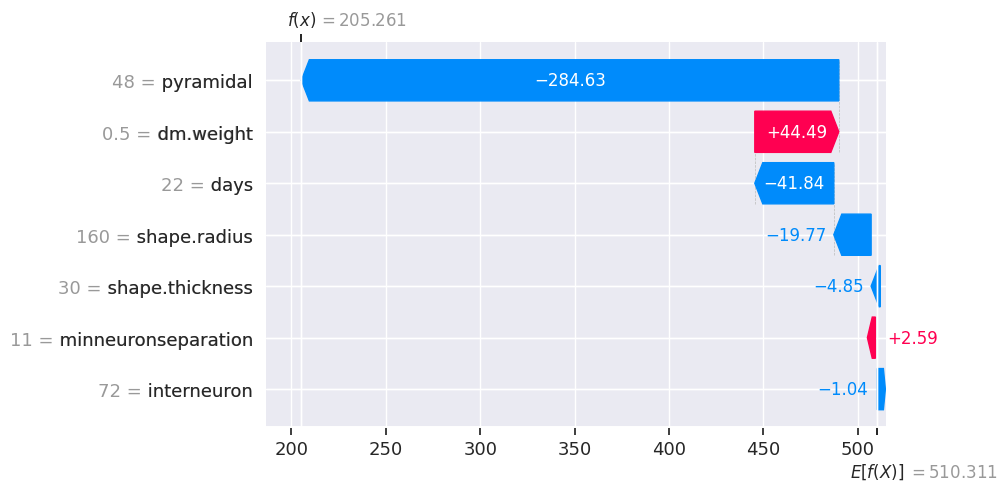

In [145]:
# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])

In [146]:
# shap.summary_plot(shap_values, X_train)

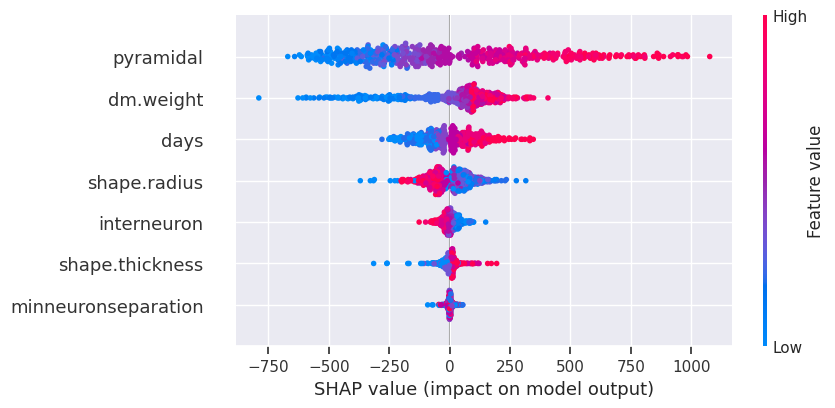

In [147]:
# summarize the effects of all the features
shap.plots.beeswarm(shap_values)

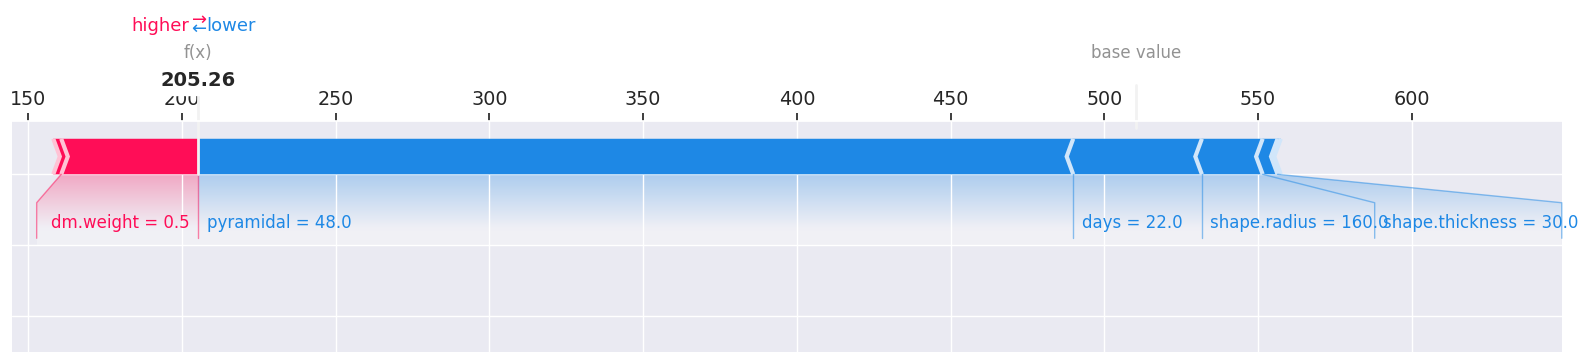

In [148]:
# visualize the first prediction's explanation with a force plot
shap.plots.force(shap_values[0], matplotlib=True)

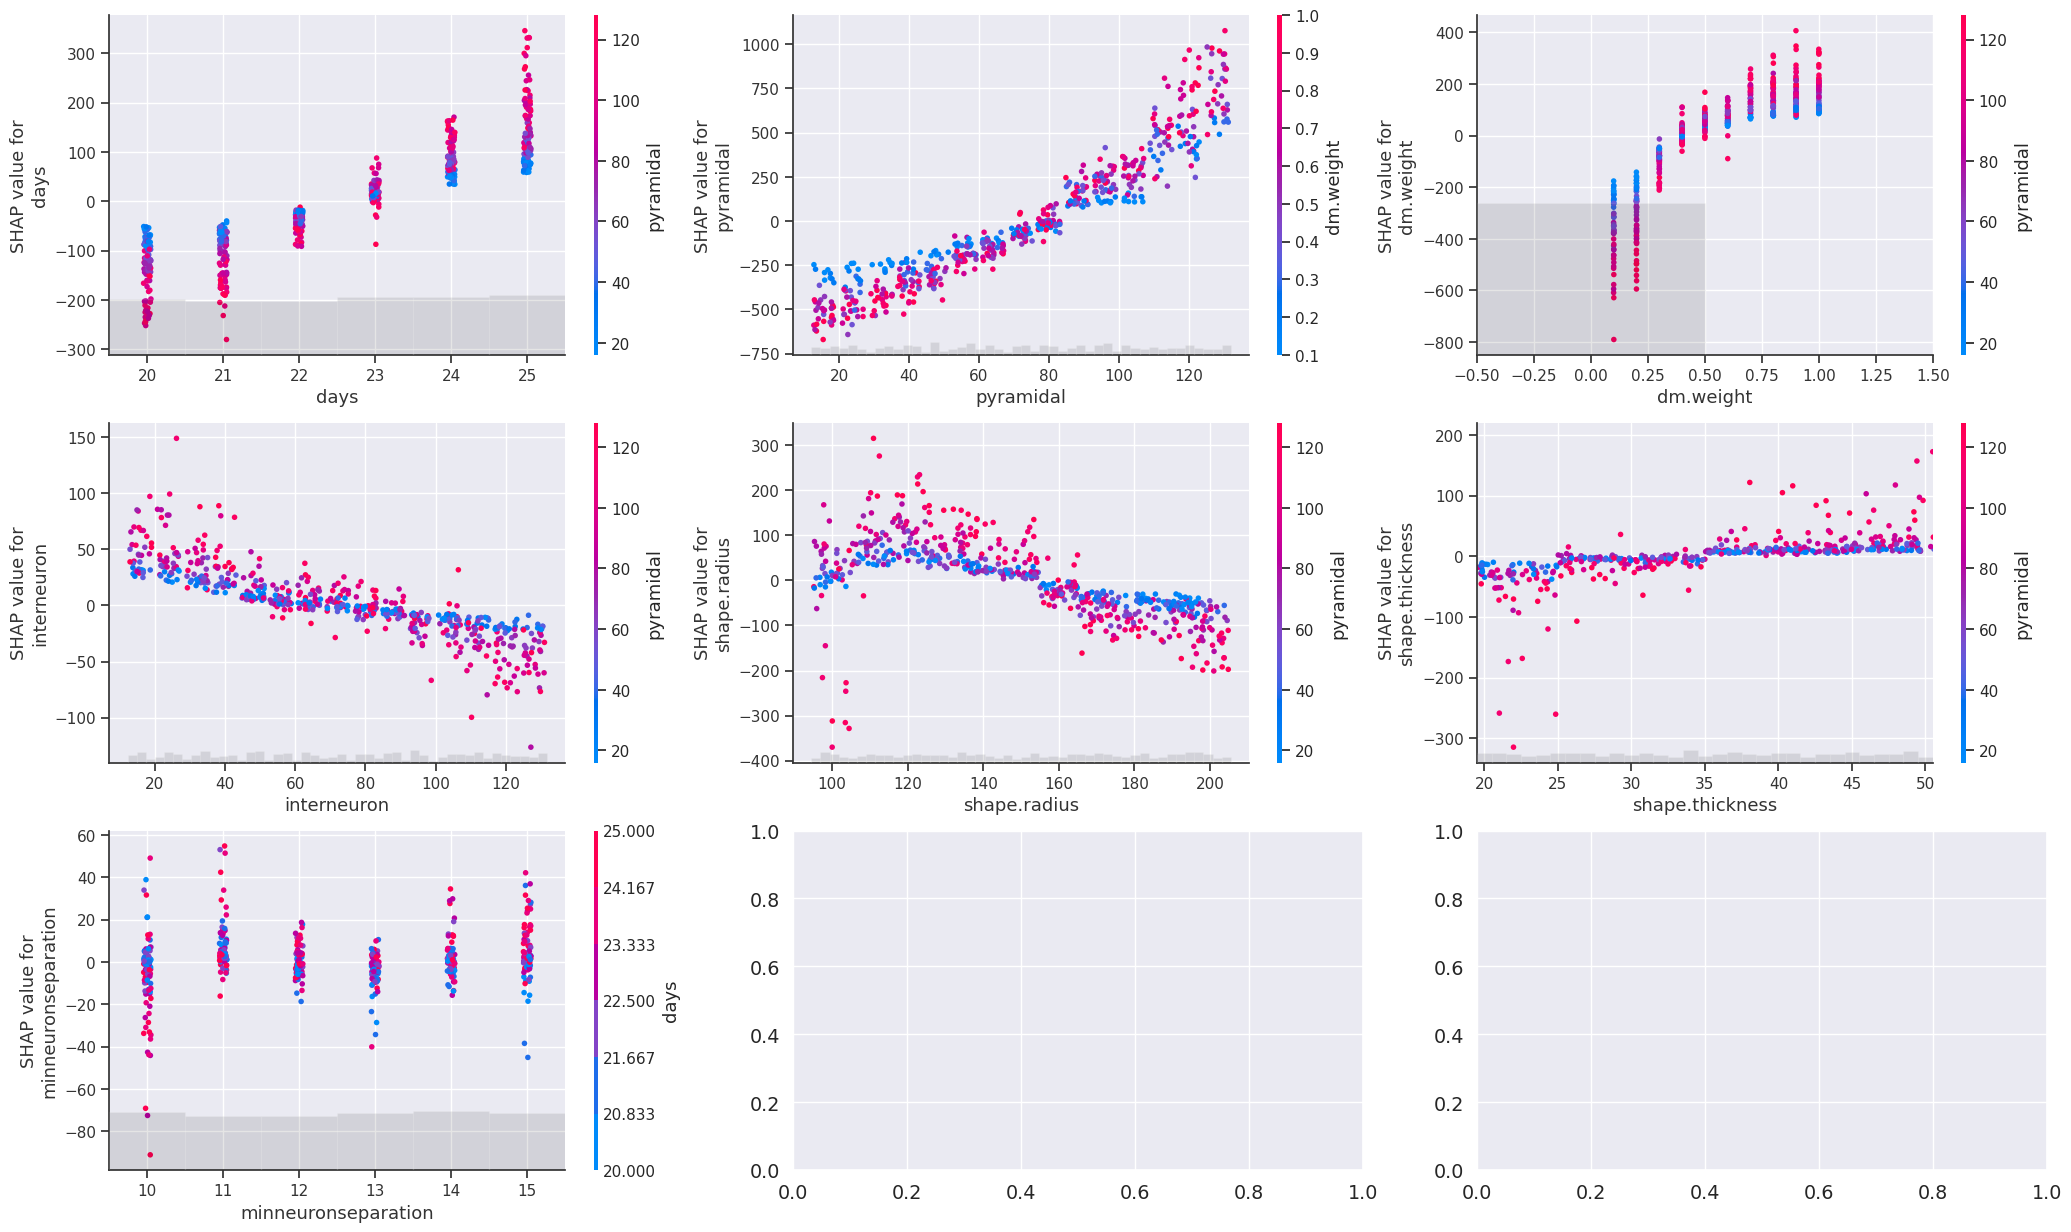

In [220]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(25, 15))

shap.plots.scatter(shap_values[:, "days"], ax=axes[0, 0], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "pyramidal"], ax=axes[0, 1], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "dm.weight"], ax=axes[0, 2], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "interneuron"], ax=axes[1, 0], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "shape.radius"], ax=axes[1, 1], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "shape.thickness"], ax=axes[1, 2], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "minneuronseparation"], ax=axes[2, 0], color=shap_values, show=False)

plt.show()

In [149]:
shap_values.shape

(560, 7)

In [150]:
shap_values[0]

.values =
array([ -41.84417259, -284.63220292,   -1.04236228,    2.58910635,
        -19.76625299,   -4.846462  ,   44.49239465])

.base_values =
np.float64(510.31095178571434)

.data =
array([ 22. ,  48. ,  72. ,  11. , 160. ,  30. ,   0.5])

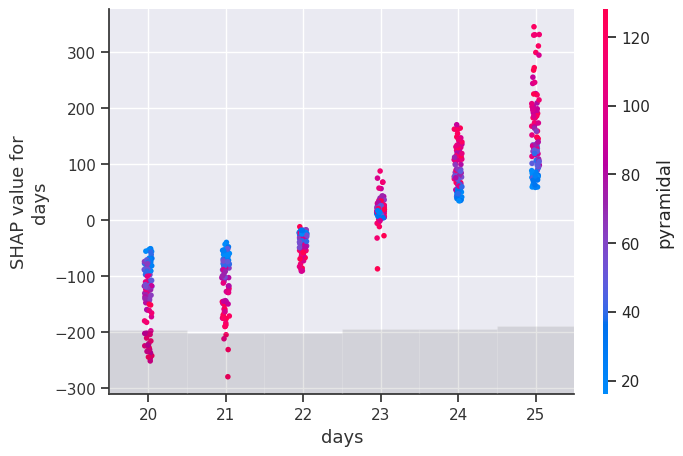

In [151]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "days"], color=shap_values)

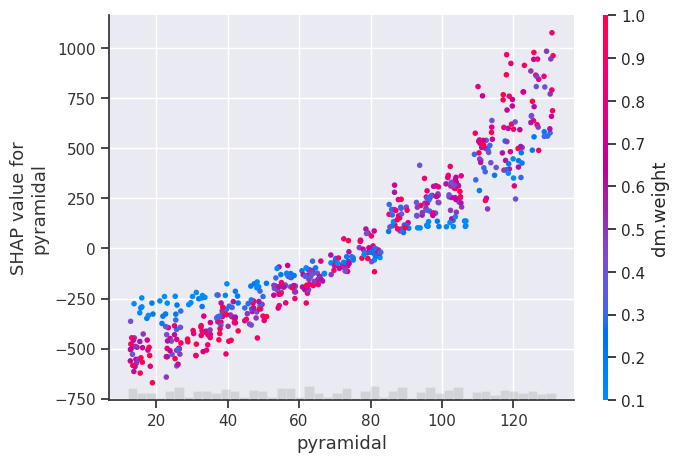

In [152]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "pyramidal"], color=shap_values)

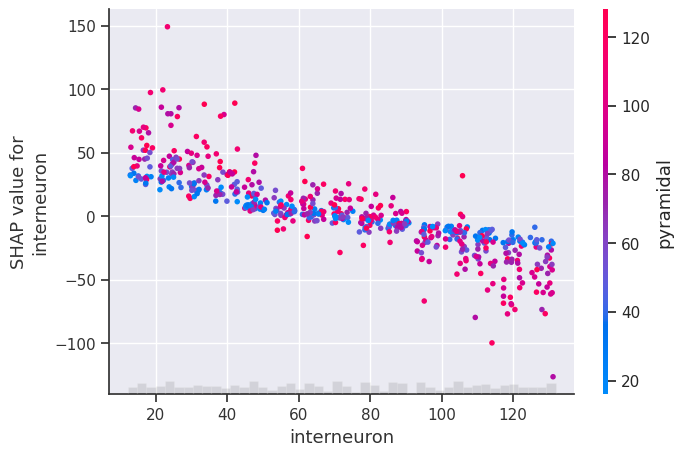

In [153]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "interneuron"], color=shap_values)


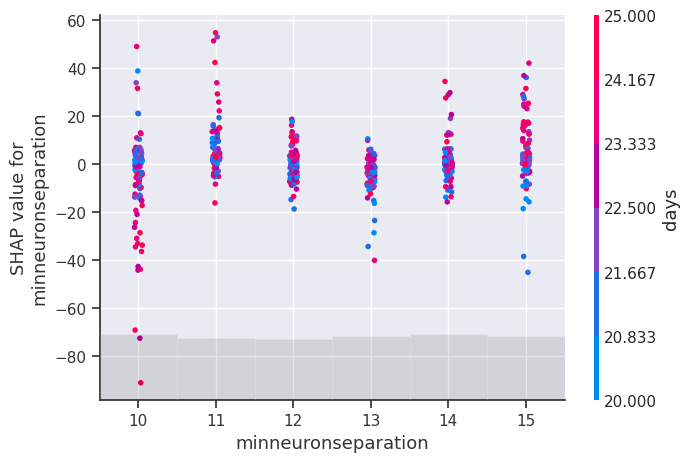

In [154]:
shap.plots.scatter(shap_values[:, "minneuronseparation"], color=shap_values)

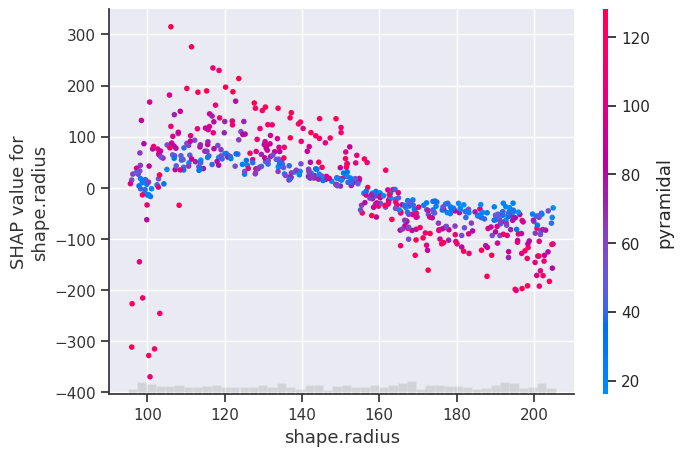

In [155]:
shap.plots.scatter(shap_values[:, "shape.radius"], color=shap_values)

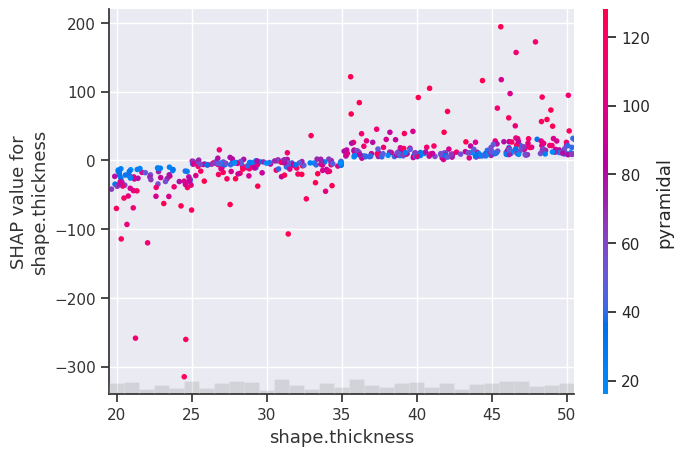

In [156]:
shap.plots.scatter(shap_values[:, "shape.thickness"], color=shap_values)

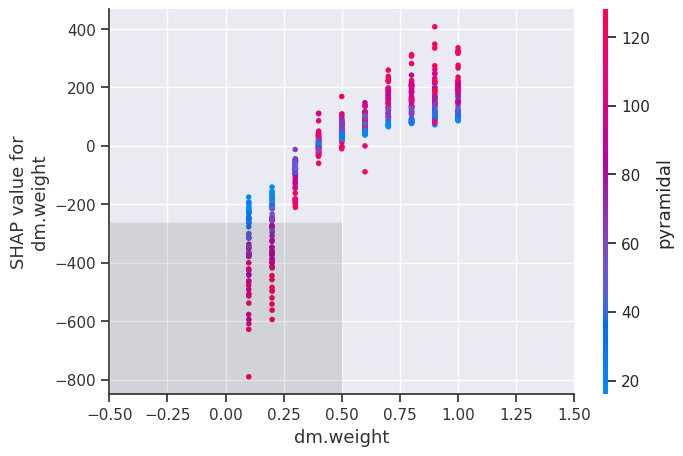

In [157]:
shap.plots.scatter(shap_values[:, "dm.weight"], color=shap_values)

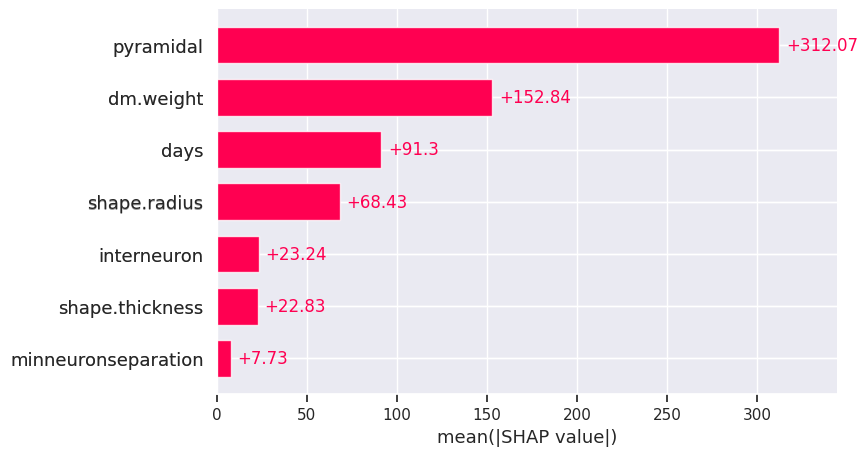

In [158]:
shap.plots.bar(shap_values)

## Create Paartial Dependence Plots (PDP)

#### PDP = average of model outcomes for fixed feature xi, while others vary.

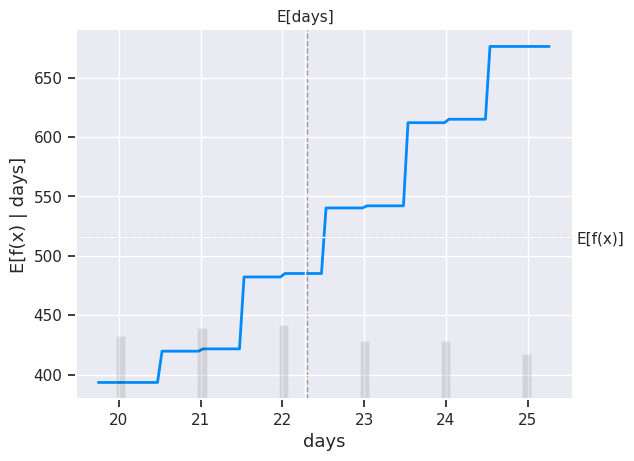

In [159]:
shap.partial_dependence_plot(
    "days",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

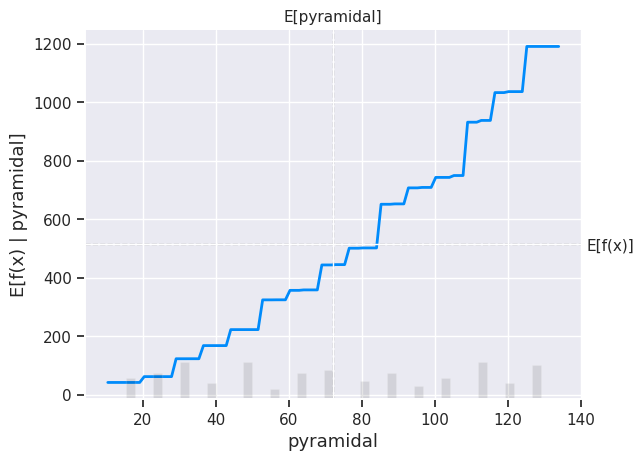

In [160]:
shap.partial_dependence_plot(
    "pyramidal",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

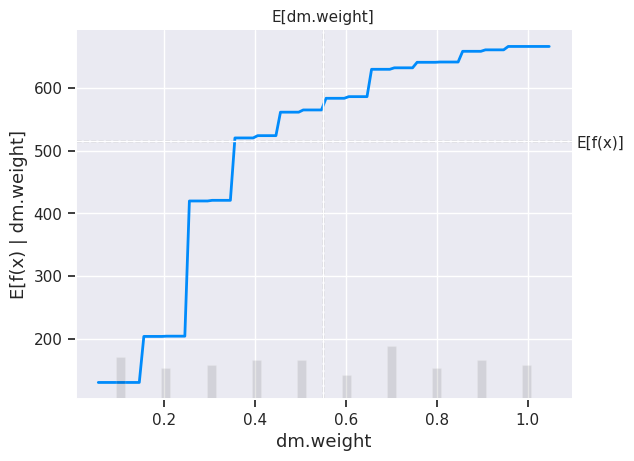

In [161]:
shap.partial_dependence_plot(
    "dm.weight",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

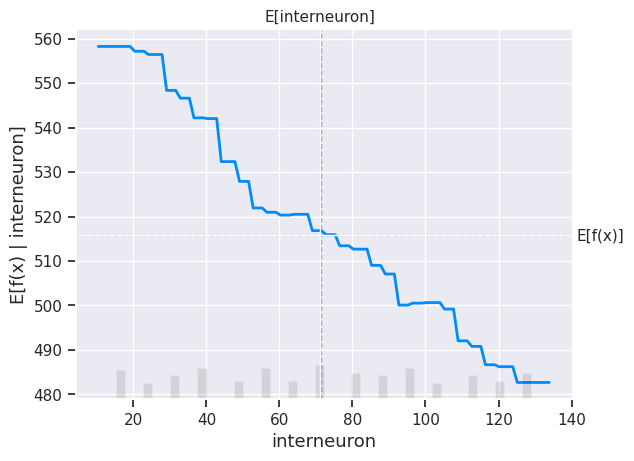

In [162]:
shap.partial_dependence_plot(
    "interneuron",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

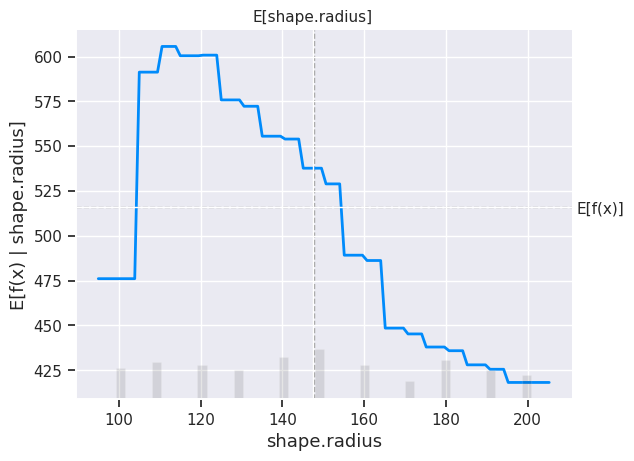

In [163]:
shap.partial_dependence_plot(
    "shape.radius",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

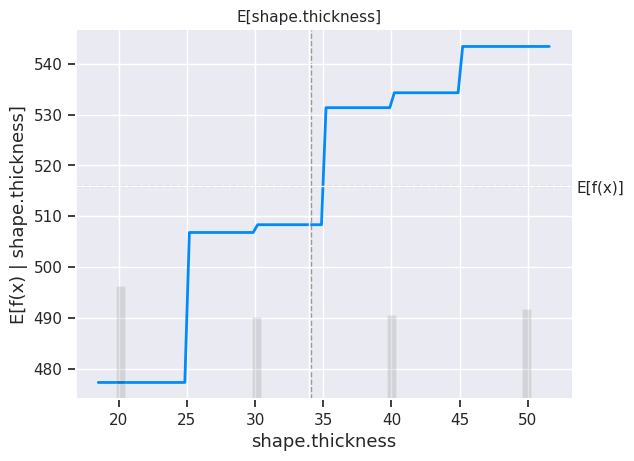

In [164]:
shap.partial_dependence_plot(
    "shape.thickness",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

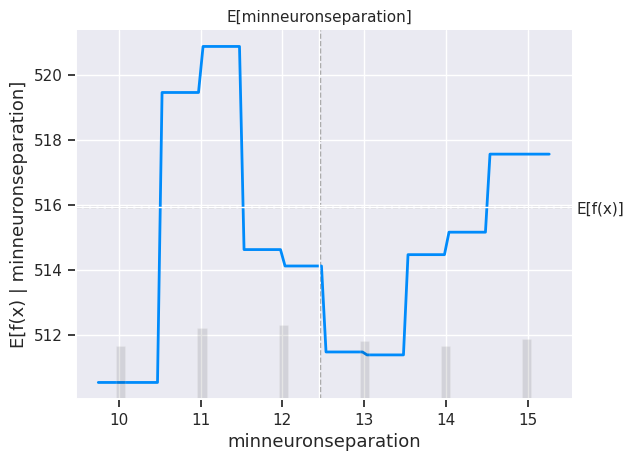

In [165]:
shap.partial_dependence_plot(
    "minneuronseparation",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

# Generate Diverse Counterfactual Explanations (DiCE)

In [166]:
qrf = RandomForestQuantileRegressor(n_estimators=1000, bootstrap = True, oob_score = True, random_state = 27, default_quantiles=0.025)
qrf.fit(X_train, y_train)

# If your oob_score is high (e.g., > 0.8), model is generalizing well.
# If your oob_score is low but your training score is high, your model is "memorizing" the training simulations 
# and your uncertainty intervals (error bars) will be lies—they will look small, but the model will fail on new unseen simulations.

print("OOB Score = ", qrf.oob_score_)

# Get OOB predictions (Predictions on the training set using only 'unseen' trees)
# This is a 'honest' way to see how the model performs on known data
oob_preds = qrf.predict(X_train[cols], quantiles=[0.025, 0.5, 0.975], oob_score=True)

# Check: Do ~95% of your actual training labels fall within these OOB intervals?
# If yes, your error bars are well-calibrated.

# Separate the OOB bounds
oob_lower = oob_preds[:, 0]
oob_median = oob_preds[:, 1]
oob_upper = oob_preds[:, 2]


OOB Score =  0.8133170240573896


#### Predict usable_conns2 on training data using Best Fit Model

Create Upper and lower bounds of 95% Prediction Interval for each prediction in the Training and Test Datasets.

In [167]:
# predict on training data
X_train['Pred_usable_conns2'] = oob_median
X_train['lower']=oob_lower
X_train['upper']=oob_upper
X_train['usable_conns2'] = y_train


In [168]:
# Predict on test data. Sine Model has never see the test data, we can use the full model (all trees) to predict on test data (No need for OOB).

X_test['Pred_usable_conns2'] = qrf.predict(X_test[cols], quantiles=0.5)
X_test['lower']=qrf.predict(X_test[cols], quantiles=0.025) 
X_test['upper']=qrf.predict(X_test[cols], quantiles=0.975) 
X_test['usable_conns2'] = y_test

In [169]:
X_train.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,lower,upper,usable_conns2
623,22,48,72,11,160,30,0.5,243.0,67.000,533.8,193
372,20,48,40,14,190,20,0.9,173.0,71.425,422.0,208
246,22,64,16,13,160,50,0.8,476.0,205.000,707.0,521
38,21,88,128,14,200,40,0.6,467.0,0.000,695.0,311
562,24,104,32,15,180,40,0.8,1148.0,732.350,1730.0,1218


In [170]:
X_test.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,lower,upper,usable_conns2
113,23,128,104,12,140,30,0.6,1249.5,623.5,2429.0,2103
596,22,64,32,14,140,50,0.6,521.0,225.0,689.0,475
177,25,24,40,10,180,50,0.7,83.0,28.0,109.0,86
473,20,128,112,11,150,30,0.7,1342.0,419.0,2219.0,803
434,24,48,32,11,150,40,0.9,422.0,174.0,503.0,325


In [ ]:

# 2. Create a "Conservative" Model Wrapper
# This wrapper tells the optimizer to look at the BOTTOM of the 95% interval
# Conservative Strategy: Optimize features until the bottom of the 95% interval is above the threshold. This ensures we hit our goal with 97.5% confidence (one-tailed).
class ConservativeModel:
    def __init__(self, model, threshold):
        self.model = model
        self.threshold = threshold
    
    def predict(self, instances):
        # We predict the 0.025 quantile (Lower Bound)
        # If the Lower Bound > threshold, we are 97.5% sure the real value is too.
        return self.model.predict(instances, quantiles=0.025)

In [172]:

# Wrap the model for DiCE
conservative_wrapper = ConservativeModel(qrf, threshold=500)
m = dice_ml.Model(model=conservative_wrapper, backend="sklearn", model_type='regressor')

# 3. Setup DiCE with specific NETMORPH features
# Setup Data with discrete ranges
# Even if they are integers, we list them in continuous_features 
# so DiCE can explore the range [min, max]
d = dice_ml.Data(dataframe=pd.concat([X_train[cols], y_train], axis=1), 
                 continuous_features=cols, 
                 outcome_name='usable_conns2')

exp = dice_ml.Dice(d, m, method="random")


In [173]:

# 4. Generate Counterfactuals
# We search for parameters where the LOWER BOUND of the model is > threshold
query_instance = X_test[cols].iloc[0:2]
dice_exp = exp.generate_counterfactuals(
    query_instance, 
    total_CFs=7, 
    desired_range=[500.0, 2500.0], # Target range for the lower bound
    permitted_range={'days': [20,25], 
                     'pyramidal': [16, 128], 
                     'interneuron': [16, 128], 
                     'minneuronseparation': [10, 15], 
                     'shape.radius': [100, 200], 
                     'shape.thickness': [20.0, 50.0], 
                     'dm.weight': [0.1, 1.0]},
    features_to_vary=list(cols)
)

dice_exp.visualize_as_dataframe(show_only_changes=True)

cf_df = dice_exp.cf_examples_list[0].final_cfs_df



100%|██████████| 2/2 [00:05<00:00,  2.53s/it]

Query instance (original outcome : 624.0)


,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,23,128,104,12,140,30,0.6,624.0



Diverse Counterfactual set (new outcome: [500.0, 2500.0])


,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,-,-,-,-,-,48.0,-,740.6749877929688
1,-,121.0,-,-,-,-,0.8,858.0
2,-,-,-,-,144.0,-,-,-
3,-,-,72.0,-,-,-,-,909.0
4,-,-,-,14.0,126.0,-,-,695.0
5,-,-,-,-,170.0,-,0.9,739.0
6,-,-,49.0,-,156.0,-,-,746.0


Query instance (original outcome : 225.0)


,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,22,64,32,14,140,50,0.6,225.0



Diverse Counterfactual set (new outcome: [500.0, 2500.0])


,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,-,128.0,-,-,-,-,0.4,688.0750122070312
1,-,125.0,69.0,-,-,-,-,749.9500122070312
2,-,126.0,-,-,-,21.0,-,652.0
3,-,127.0,-,-,-,-,-,909.0
4,24.0,86.0,-,-,-,-,-,581.75
5,-,126.0,-,-,-,-,0.4,688.0750122070312
6,-,113.0,-,-,-,-,0.8,719.9500122070312


In [174]:
print(cf_df.shape)
print(cf_df)


(7, 8)
   days  pyramidal  interneuron  minneuronseparation  shape.radius  \
0    23        128          104                   12           140   
1    23        121          104                   12           140   
2    23        128          104                   12           144   
3    23        128           72                   12           140   
4    23        128          104                   14           126   
5    23        128          104                   12           170   
6    23        128           49                   12           156   

   shape.thickness  dm.weight  usable_conns2  
0               48        0.6          741.0  
1               30        0.8          858.0  
2               30        0.6          651.0  
3               30        0.6          909.0  
4               30        0.6          695.0  
5               30        0.9          739.0  
6               30        0.6          746.0  


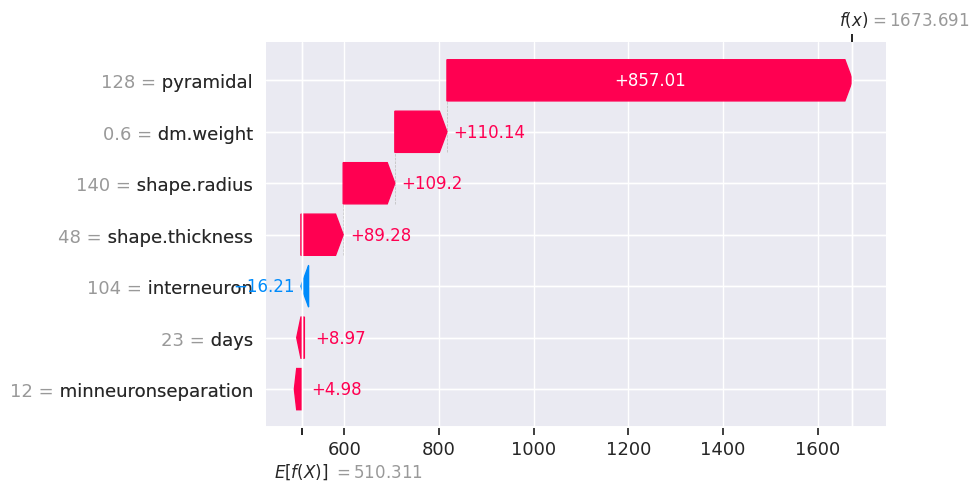

In [180]:
shap_values_cf = explainer(cf_df[cols])
# visualize the cf prediction's explanation
shap.plots.waterfall(shap_values_cf[0])

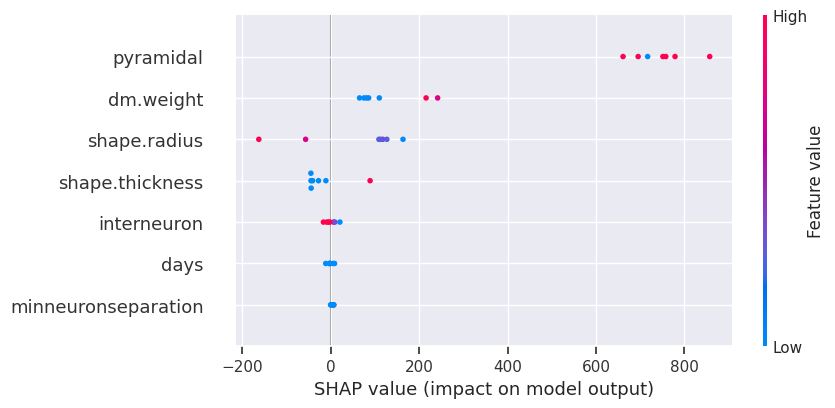

In [181]:
shap.plots.beeswarm(shap_values_cf)

In [177]:
dice_exp.cf_examples_list[0].final_cfs_df

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,23,128,104,12,140,48,0.6,741.0
1,23,121,104,12,140,30,0.8,858.0
2,23,128,104,12,144,30,0.6,651.0
3,23,128,72,12,140,30,0.6,909.0
4,23,128,104,14,126,30,0.6,695.0
5,23,128,104,12,170,30,0.9,739.0
6,23,128,49,12,156,30,0.6,746.0


In [178]:
X_train.sort_values(by='Pred_usable_conns2', ascending=False, inplace = True)
X_train.reset_index(drop=True, inplace=True)


X_test.sort_values(by='Pred_usable_conns2', ascending=False, inplace = True)
X_test.reset_index(drop=True, inplace=True)

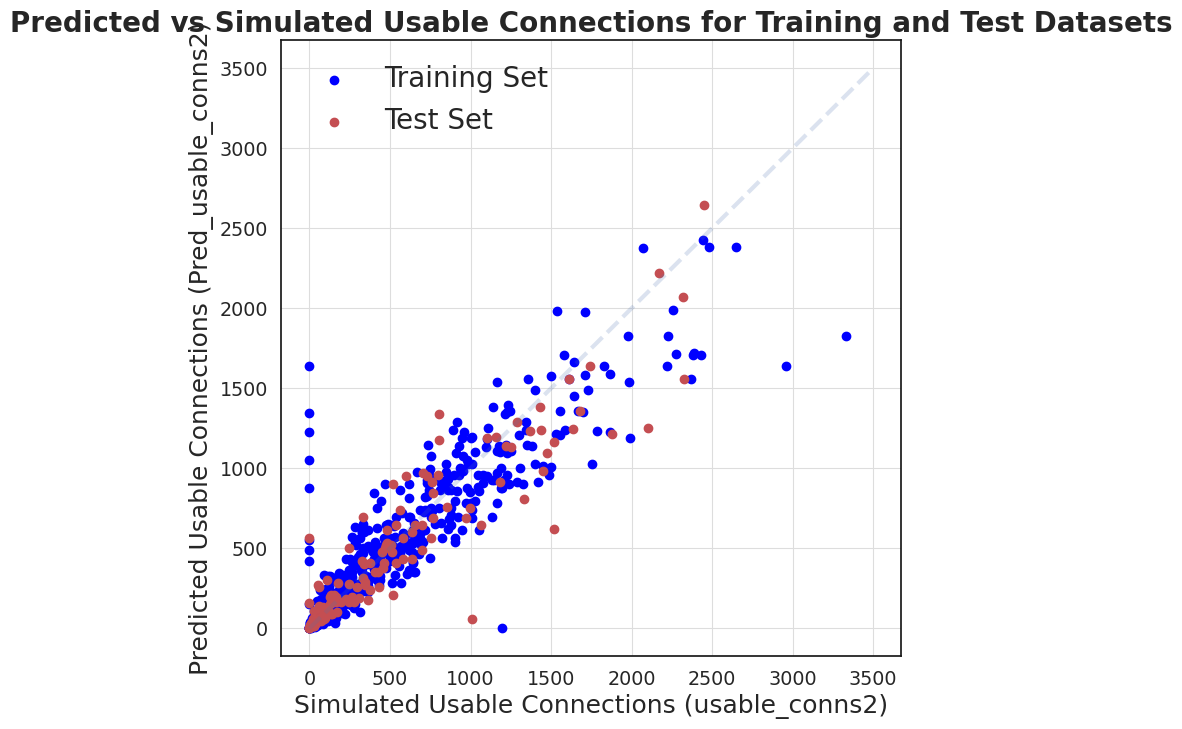

In [179]:
f, ax = plt.subplots(figsize=(8, 8))

plt.scatter(X_train['usable_conns2'], X_train['Pred_usable_conns2'], color ='blue', label = 'Training Set')
plt.scatter(X_test['usable_conns2'],  X_test['Pred_usable_conns2'],color ='r', label = 'Test Set')
# plt.errorbar(X_test['usable_conns2'],  X_test['Pred_usable_conns2'], yerr = X_test['Pred_Usable_Conns_Err'], fmt='o',color ='r', label = 'Test Set')

# plt.fill_between(X_train['usable_conns2'], X_train['Pred_usable_conns2']-1.96*X_train['Pred_Usable_Conns_Err'], X_train['Pred_usable_conns2'] + 1.96*X_train['Pred_Usable_Conns_Err'], color='r', alpha=0.25, label = '95% CI')
# plt.scatter(X_train['usable_conns2'], X_train['Pred_usable_conns2']-1.96*X_train['Pred_Usable_Conns_Err'], color ='cyan', marker='+' )
# plt.scatter(X_train['usable_conns2'], X_train['Pred_usable_conns2']+1.96*X_train['Pred_Usable_Conns_Err'], color ='green', marker='+' )

# plt.fill_between(X_train['usable_conns2'], X_train['lower'], X_train['upper'], color='r', alpha=0.25, label = '95% CI')
# plt.scatter(X_train['usable_conns2'], X_train['lower'], color ='cyan', marker='+' )
# plt.scatter(X_train['usable_conns2'], X_train['upper'], color ='green', marker='+' )

plt.plot(np.linspace(0,3500,1000), np.linspace(0,3500, 1000), 'b--', linewidth=3, alpha= 0.2)

plt.gca().set_facecolor('xkcd:white')
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)


ax.spines['bottom'].set_color('k')
ax.spines['top'].set_color('k')
ax.spines['left'].set_color('k')
ax.spines['right'].set_color('k')

# plt.xlim([0,3500])
# plt.ylim([0,3500])
plt.rc('font', size=18) 
plt.rc('font', size=18) 

plt.title('Predicted vs Simulated Usable Connections for Training and Test Datasets',size = 20, fontweight="bold")
plt.xlabel('Simulated Usable Connections (usable_conns2)',size =18)
plt.ylabel('Predicted Usable Connections (Pred_usable_conns2)',size = 18)
plt.legend(loc='upper left', prop={'size': 20},framealpha=0.)
plt.show()
# f.savefig('Pred_vs_Sim_UsableConns.png')